In [123]:
!uv pip install mpltern

Using Python 3.13.9 environment at: C:\Users\Asus\Documents\14_PrixChangementClimatique\.venv
Resolved 12 packages in 591ms
Prepared 1 package in 79ms
Installed 1 package in 22ms
 + mpltern==1.0.4


In [1]:
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px

import folium
from folium.plugins import TimeSliderChoropleth
import branca.colormap as cm
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# PySAL
from inequality.gini import Gini
from inequality.theil import Theil

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, HDBSCAN, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Removing warnings
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Connection
con = duckdb.connect("dev.duckdb", read_only=True)
con.sql("LOAD spatial;")  # if geospatial data needed

In [3]:
dept_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-avec-outre-mer.geojson"
communes_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson"

dept_geo = gpd.read_file(dept_geojson_url)
communes_geo = gpd.read_file(communes_geojson_url)

In [4]:
def prepare_france_geometry(df):
    if df.crs != "EPSG:2154":
        df = df.to_crs(epsg=2154)

    df['dept_temp'] = df['code'].apply(lambda x: x[:3] if x.startswith('97') else x[:2])

    drom_configs = {
        '971': {'pos': (-150000, 6540000), 'scale': 1.3, 'name': "Guadeloupe"},
        '972': {'pos': (50000, 6540000),   'scale': 1.8, 'name': "Martinique"},
        '973': {'pos': (-150000, 6140000), 'scale': 0.25, 'name': "Guyane"},
        '974': {'pos': (-150000, 6340000), 'scale': 1, 'name': "La Réunion"},
        '976': {'pos': (50000, 6340000),   'scale': 2.5, 'name': "Mayotte"},
    }

    df_main = df[~df['dept_temp'].str.startswith('97')].copy()
    df_droms = []

    for code, cfg in drom_configs.items():
        drom = df[df['dept_temp'] == code].copy()
        if not drom.empty:
            centroid = drom.geometry.unary_union.centroid
            drom.geometry = drom.geometry.translate(xoff=-centroid.x, yoff=-centroid.y)
            drom.geometry = drom.geometry.scale(xfact=cfg['scale'], yfact=cfg['scale'], origin=(0,0))

            # Box Position
            drom.geometry = drom.geometry.translate(xoff=cfg['pos'][0], yoff=cfg['pos'][1])
            df_droms.append(drom)

    return gpd.pd.concat([df_main] + df_droms), drom_configs


def monovariate_map(df, col="taux_non_rec_global", cmap="copper_r", 
                    title="Taux de non-reconnaissance par commune", 
                    missing_color="white", norm=None, 
                    legend_label="(%)",
                    subtitle=None, linewidth=0.1, colorbar=True):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        norm=norm,
        legend=colorbar,
        legend_kwds={"shrink": 0.4, "pad": -0.05},
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth, 
    )

    cbar_ax = ax.get_figure().get_axes()[-1]
    cbar_ax.set_ylabel(f" {legend_label}", color="black")

    if subtitle:
        ax.text(0.5, 0.99, subtitle, transform=ax.transAxes, 
                fontsize=14, color='dimgray', ha='center', style='italic')

    # Box size (width, height) in meters
    box_w, box_h = 180000, 150000 

    for code, cfg in drom_configs.items():
        x, y = cfg['pos']
        rect = mpatches.Rectangle(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            linewidth=0.5, edgecolor='gray', facecolor='none', 
            linestyle='--', alpha=0.6
        )
        ax.add_patch(rect)

        # Add label above each box
        ax.text(x, y + (box_h/2) + 12500, cfg['name'], 
                fontsize=9, ha='center', color='dimgray')

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15, color="black")

    null_patch = mpatches.Patch(color=missing_color, label="Pas de cas", edgecolor="black")
    leg = ax.legend(handles=[null_patch], loc="lower left", frameon=False, bbox_to_anchor=(0.5, 0.025))

    plt.setp(leg.get_texts(), color='black', fontsize=10) 

    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig


def cluster_map(df, col="clusters", cmap="Set1", 
                    title="Typologie du Risque Assurantiel", 
                    missing_color="white", 
                    legend_labels=None,
                    subtitle=None, linewidth=0.1):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        categorical=True,
        legend=False, 
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth, 
    )

    if subtitle:
        ax.text(0.5, 0.99, subtitle, transform=ax.transAxes, 
                fontsize=14, color='dimgray', ha='center', style='italic')

    box_w, box_h = 180000, 150000 
    for code, cfg in drom_configs.items():
        x, y = cfg['pos']
        rect = mpatches.Rectangle(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            linewidth=0.5, edgecolor='gray', facecolor='none', 
            linestyle='--', alpha=0.6
        )
        ax.add_patch(rect)
        ax.text(x, y + (box_h/2) + 12500, cfg['name'], 
                fontsize=9, ha='center', color='dimgray')

    unique_clusters = sorted(df_plot[col].dropna().unique())
    colormap = plt.get_cmap(cmap)
    
    legend_handles = []
    for i, cluster_id in enumerate(unique_clusters):
        color = colormap(i / max(1, len(unique_clusters) - 1)) if len(unique_clusters) > 1 else colormap(0)
        
        label = legend_labels[cluster_id] if legend_labels and cluster_id in legend_labels else f"Cluster {int(cluster_id)}"
        
        patch = mpatches.Patch(color=color, label=label, edgecolor="black", linewidth=0.5)
        legend_handles.append(patch)

    null_patch = mpatches.Patch(color=missing_color, label="Pas de données", edgecolor="black", linewidth=0.5)
    legend_handles.append(null_patch)

    leg = ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(0.9, 0.5), 
                    frameon=True, title="Profils de Risque", fontsize=11, title_fontsize=13)
    plt.setp(leg.get_texts(), color='black') 

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15, color="black")
    
    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig

In [5]:
def inequality_analysis(df, filter="region_name", var="dettes", label=False):
    df_stats = df.groupby([filter, 'annee'])[var].agg(
        min_solde='min',
        q1_solde=lambda x: x.quantile(0.25),
        median_solde='median',
        mean_solde='mean',
        q3_solde=lambda x: x.quantile(0.75),
        max_solde='max',
        count_communes='count'
    ).reset_index()
    
    df_stats['iqr_solde'] = df_stats['q3_solde'] - df_stats['q1_solde']
    df_stats['max_min_solde'] = df_stats['max_solde'] - df_stats['min_solde']
    
    def compute_pysal_gini(x):
        if len(x) < 2 or x.mean() == 0:
            return 0
        return Gini(x.values).g
    
    gini_results = df.groupby([filter])[var].apply(compute_pysal_gini).reset_index()
    gini_results.rename(columns={var: 'gini'}, inplace=True)

    zone_comp = df_stats.groupby(filter)[['iqr_solde', 'max_min_solde', 'mean_solde']].mean().reset_index()
    zone_comp = zone_comp.merge(gini_results, on=filter)
    
    plt.figure(figsize=(14, 9))
    
    scatter = sns.scatterplot(
        data=zone_comp, 
        x='iqr_solde', 
        y='max_min_solde', 
        size='mean_solde', 
        sizes=(100, 1000), 
        #hue='gini',  
        edgecolor='black',
        alpha=0.7
    )

    if label: 
        for i in range(zone_comp.shape[0]):
            plt.text(
                x=zone_comp.iqr_solde[i]*1.1, 
                y=zone_comp.max_min_solde[i] * 0.725, # Position text slightly above point
                s=zone_comp[filter][i], 
                fontsize=10, 
                ha='center',
                fontweight='semibold'
            )
    
    plt.title("Regional Debt Personalities\n(Inner Inequality vs. Absolute Disparity)", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel("Median IQR (Spread of the 'Middle' 50% of towns)", fontsize=13)
    plt.ylabel("Median Max-Min (Gap between Richest and Poorest town)", fontsize=13)
    
    plt.yscale('log')
    plt.xscale('log')
    
    plt.tight_layout()
    plt.show()

    return df_stats, zone_comp

def plot_personality_evolution(df_stats, col, label=False):

    plt.figure(figsize=(14, 10))
    
    # 2. Draw the 'Path' for each region
    # We use lineplot first so the lines sit behind the dots
    sns.lineplot(
        data=df_stats, 
        x='iqr_solde', y='max_min_solde', 
        hue=col, 
        sort=False, alpha=0.4, legend=False,
        linewidth=2
    )
    
    # 3. Draw the Scatter points
    # Size reflects the year so newer years look more prominent
    scatter = sns.scatterplot(
        data=df_stats, 
        x='iqr_solde', y='max_min_solde', 
        hue=col, 
        size='annee', 
        sizes=(40, 400),
        alpha=0.8,
        edgecolor='black'
    )

    if label:    
        latest_year = df_stats['annee'].max()
        for i, row in df_stats[df_stats['annee'] == latest_year].iterrows():
            plt.text(
                row['iqr_solde'], row['max_min_solde'] * 1.3, 
                row[col], 
                fontsize=10, fontweight='bold', ha='center',
                color='black'
            )
    
    # 5. Log Scales and Styling
    plt.xscale('log')
    plt.yscale('log')
    
    plt.title(f"Evolution of Regional Debt Personalities ({df_stats['annee'].min()} - {latest_year})", 
              fontsize=16, fontweight='bold')
    plt.xlabel("IQR (Middle 50% Spread) - Log Scale")
    plt.ylabel("Max-Min Gap (Absolute Range) - Log Scale")
    
    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Regions & Year Size")
    
    plt.tight_layout()
    plt.show()

In [6]:
DEPT_TO_REG = {
    '01': 84, '03': 84, '07': 84, '15': 84, '26': 84, '38': 84, '42': 84, '43': 84, '63': 84, '69': 84, '73': 84, '74': 84,
    '75': 11, '77': 11, '78': 11, '91': 11, '92': 11, '93': 11, '94': 11, '95': 11,
    '04': 93, '05': 93, '06': 93, '13': 93, '83': 93, '84': 93,
    '16': 75, '17': 75, '19': 75, '23': 75, '24': 75, '33': 75, '40': 75, '47': 75, '64': 75, '79': 75, '86': 75, '87': 75,
    '09': 76, '11': 76, '12': 76, '30': 76, '31': 76, '32': 76, '34': 76, '46': 76, '48': 76, '65': 76, '66': 76, '81': 76, '82': 76,
    '02': 32, '59': 32, '60': 32, '62': 32, '80': 32,
    '08': 44, '10': 44, '51': 44, '52': 44, '54': 44, '55': 44, '57': 44, '67': 44, '68': 44, '88': 44,
    '44': 52, '49': 52, '53': 52, '72': 52, '85': 52,
    '22': 53, '29': 53, '35': 53, '56': 53,
    '14': 28, '27': 28, '50': 28, '61': 28, '76': 28,
    '21': 27, '25': 27, '39': 27, '58': 27, '70': 27, '71': 27, '89': 27, '90': 27,
    '18': 24, '28': 24, '36': 24, '37': 24, '41': 24, '45': 24,
    '2A': 94, '2B': 94, '20': 94,
    '971': 1, '972': 2, '973': 3, '974': 4, '976': 6
}

REG_NAMES = {
    84: "Auvergne-Rhône-Alpes", 11: "Île-de-France", 93: "Provence-Alpes-Côte d'Azur",
    75: "Nouvelle-Aquitaine", 76: "Occitanie", 32: "Hauts-de-France", 44: "Grand Est",
    52: "Pays de la Loire", 53: "Bretagne", 28: "Normandie", 27: "Bourgogne-Franche-Comté",
    24: "Centre-Val de Loire", 94: "Corse", 1: "Guadeloupe", 2: "Martinique",
    3: "Guyane", 4: "La Réunion", 6: "Mayotte"
}

def get_dept(code):
    code = str(code).zfill(5) 
    
    if code.startswith(('97', '98')):
        return code[:3]
    return code[:2]

def get_region(insee_code):
    code = str(insee_code).zfill(5)
    if code.startswith(('97', '98')):
        dept = code[:3]
    else:
        dept = code[:2]
    return DEPT_TO_REG.get(dept, "Unknown")

### __DB TABLES__

In [7]:
query_tables = """
                SHOW TABLES
                """
tables = con.sql(query_tables)
tables_df = tables.df()
tables_df

,name
0,azi_gaspar
1,bronze_rei
2,budget_communes
3,budget_per_compte_communes
4,catnat_gaspar
5,ccr_details
6,ccr_main_page
7,datactivist_commune
8,dicrim_gaspar
9,geoportail_ccr_communes


### __COMPTES COMMUNES__

In [8]:
query_budget = """
                SELECT
                    *
                FROM budget_per_compte_communes
                """

comptes = con.sql(query_budget)
comptes_df = comptes.df()
comptes_df.head()

,code_departement,code_insee,siret,siren,annee,code_region,type_compte,code_geo,code_geo_from_siren,nom_com,solde_debiteur,solde_crediteur,solde
0,68,emp,21680193600040,216801936,2014,44,depenses,68emp,68193,Luttenbach-près-Munster,102909.42,0.00,102909.42
1,68,emp,21680255300042,216802553,2014,44,depenses,68emp,68255,Pfaffenheim,190182.46,0.00,190182.46
2,69,155,21690155300018,216901553,2014,84,depenses,69155,69155,Pomeys,386782.43,3481.68,383300.75
3,69,emp,21690170200078,216901702,2014,84,depenses,69emp,69170,Rontalon,2957.50,0.00,2957.50
4,69,emp,21690220500089,216902205,2014,84,depenses,69emp,69220,Saint-Laurent-de-Chamousset,88.26,0.00,88.26


In [9]:
query_pop = """
            SELECT
                *
            FROM population_code_geo
            """

pop = con.sql(query_pop)
pop_df = pop.df()

pop_df.columns = pop_df.columns.str.replace('pop_', '')
pop_df = pop_df.drop(columns=['nom_geo', 'code_departement', 'code_region'])
pop_long = pop_df.melt(
    id_vars=['code_geo'], 
    var_name='annee', 
    value_name='population'
)
pop_long["annee"] = pop_long["annee"].astype(int)

In [10]:
comptes_df = comptes_df[comptes_df["code_geo_from_siren"].isin(communes_geo["code"])]
comptes_df["region_id"] = comptes_df["code_geo_from_siren"].apply(get_region)
comptes_df["region_name"] = comptes_df["region_id"].map(REG_NAMES)

In [93]:
types_to_keep = ["dettes financieres", "primes d assurances", "depenses", "produits"]
comptes_filtered = comptes_df[comptes_df["type_compte"].isin(types_to_keep)].copy()

comptes_final = comptes_filtered.pivot_table(
    index=["code_geo_from_siren", "nom_com", "code_departement", "region_name", "annee"], 
    columns="type_compte",                       
    values="solde",                              
    aggfunc="sum"                                
).reset_index()

comptes_final = comptes_final.rename(columns={
    "dettes financieres": "dettes",
    "primes d assurances": "primes",
    "depenses": "depenses",
    "produits": "produits"
})

comptes_final['solde_annuel'] = comptes_final['produits'] - comptes_final['depenses']
comptes_final['ratio_dette'] = (comptes_final['dettes'] / comptes_final['produits']) * 100
comptes_final['ratio_primes_depenses'] = (comptes_final['primes'] / comptes_final['depenses']) * 100

cols_to_fix = ['primes', 'dettes', 'depenses', 'produits']

for col in cols_to_fix:
    if col in comptes_final.columns:
        comptes_final[col] = comptes_final[col].abs()

""" POP per Habs
comptes_final = pd.merge(
    comptes_final, 
    pop_long, 
    on=['code_geo', 'annee'], 
    how='left'
)

cols_to_capita = ["dettes", "primes", "depenses", "produits", "solde_annuel"]

for col in cols_to_capita:
    comptes_final[f"{col}_per_capita"] = comptes_final[col] / (comptes_final['population'])
"""

comptes_final.head()

type_compte,code_geo_from_siren,nom_com,code_departement,region_name,annee,depenses,dettes,primes,produits,solde_annuel,ratio_dette,ratio_primes_depenses
0,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,2010,352412.07,304471.51,7024.81,485774.11,-838186.18,62.677591,1.993351
1,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,2011,366311.07,258563.35,7466.50,525565.08,-891876.15,49.197209,2.038295
2,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,2012,389353.35,212033.21,8033.48,516005.73,-905359.08,41.091251,2.063288
3,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,2013,432330.19,271102.64,8585.95,485289.79,-917619.98,55.864072,1.985970
4,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,2014,420008.30,412978.24,6317.78,504415.24,-924423.54,81.872673,1.504204


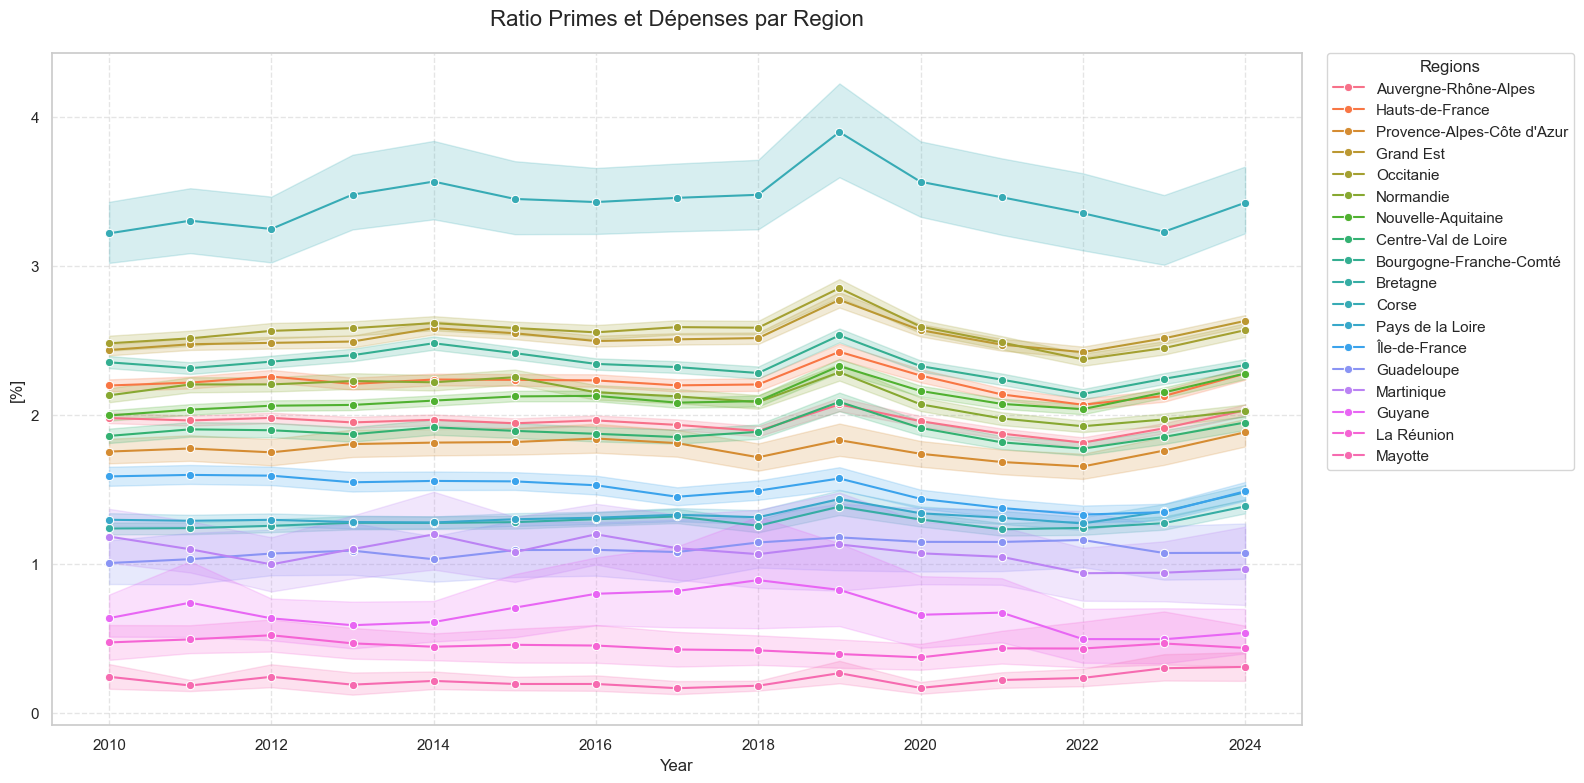

In [94]:
plt.figure(figsize=(16, 8))

ax = sns.lineplot(
    data=comptes_final,
    x="annee",
    y="ratio_primes_depenses",
    hue="region_name",
    marker='o',
)

plt.legend(title='Regions', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.title("Ratio Primes et Dépenses par Region", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("[%]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [95]:
sns.boxplot(data=comptes_final.sort_values(by="primes_per_capita", ascending=False),
            y="region_name",
            x="primes_per_capita", 
            showfliers=False)

KeyError: 'primes_per_capita'

In [96]:
def analyze_commune_risks(df, col='ratio_primes_depenses', cagr_years=3, epsilon=1e-6):
    df = df.copy()
    
    median_ratios = df.groupby(['code_geo_from_siren', 'nom_com', 'region_name'])[col].median().reset_index()
    median_ratios = median_ratios.rename(columns={col: 'historical_median'})

    latest_year = df['annee'].max()
    prev_year = latest_year - 1
    start_year_cagr = latest_year - cagr_years
    years_of_interest = [start_year_cagr, prev_year, latest_year]

    time_data = df[df['annee'].isin(years_of_interest)]
    time_data = time_data.drop_duplicates(subset=["code_geo_from_siren", "annee"])

    pivot_years = time_data.pivot(
        index='code_geo_from_siren',
        columns='annee',
        values=col
    ).reset_index()

    # Fill missing years if necessary
    for yr in years_of_interest:
        if yr not in pivot_years.columns:
            pivot_years[yr] = np.nan

    pivot_years = pivot_years.rename(columns={
        start_year_cagr: 'val_start',
        prev_year: 'val_prev',
        latest_year: 'current_ratio'
    })

    comparison_df = pd.merge(
        median_ratios, 
        pivot_years[['code_geo_from_siren', 'val_start', 'val_prev', 'current_ratio']], 
        on='code_geo_from_siren', 
        how='inner'
    )

    comparison_df['yoy_growth'] = (
        (comparison_df['current_ratio'] - comparison_df['val_prev']) / 
        (comparison_df['val_prev'] + epsilon)
    ) * 100

    comparison_df['pct_change_vs_median'] = (
        (comparison_df['current_ratio'] - comparison_df['historical_median']) / 
        (comparison_df['historical_median'] + epsilon)
    ) * 100

    comparison_df['historical_rank'] = comparison_df['historical_median'].rank(ascending=False)
    comparison_df['current_rank'] = comparison_df['current_ratio'].rank(ascending=False)
    comparison_df['rank_delta'] = comparison_df['historical_rank'] - comparison_df['current_rank']

    comparison_df['cagr_3y'] = (
        ((comparison_df['current_ratio'] + epsilon) / (comparison_df['val_start'] + epsilon))**(1/cagr_years) - 1
    ) * 100

    comparison_df = comparison_df.drop(columns=['val_start'])
    comparison_df = comparison_df.sort_values(by='yoy_growth', ascending=False)

    return comparison_df

In [125]:
cols = ["historical_median", "val_prev", "current_ratio", "historical_rank", "current_rank"]

comparison_primes_vol = analyze_commune_risks(comptes_final, col='primes', cagr_years=3)#.drop(columns=cols)
comparison_ratio_primes_depenses = analyze_commune_risks(comptes_final, col='ratio_primes_depenses', cagr_years=3)#.drop(columns=cols)
comparison_dettes = analyze_commune_risks(comptes_final, col='dettes', cagr_years=3)#.drop(columns=cols)

In [126]:
comparison_combined = pd.merge(
    comparison_primes_vol,
    comparison_ratio_primes_depenses,
    on=['code_geo_from_siren', 'nom_com', 'region_name'],
    suffixes=('_primes', '_primes_ratio')
)

comparison_combined = pd.merge(
    comparison_combined,
    comparison_dettes,
    on=['code_geo_from_siren', 'nom_com', 'region_name'],
)

comparison_combined = comparison_combined.rename(columns={
    'historical_median': 'historical_median_dettes',
    'current_ratio': 'current_ratio_dettes',
    'yoy_growth': 'yoy_growth_dettes',
    'pct_change_vs_median': 'pct_change_vs_median_dettes',
    'rank_delta': 'rank_delta_dettes',
    'cagr_3y': 'cagr_3y_dettes'
})

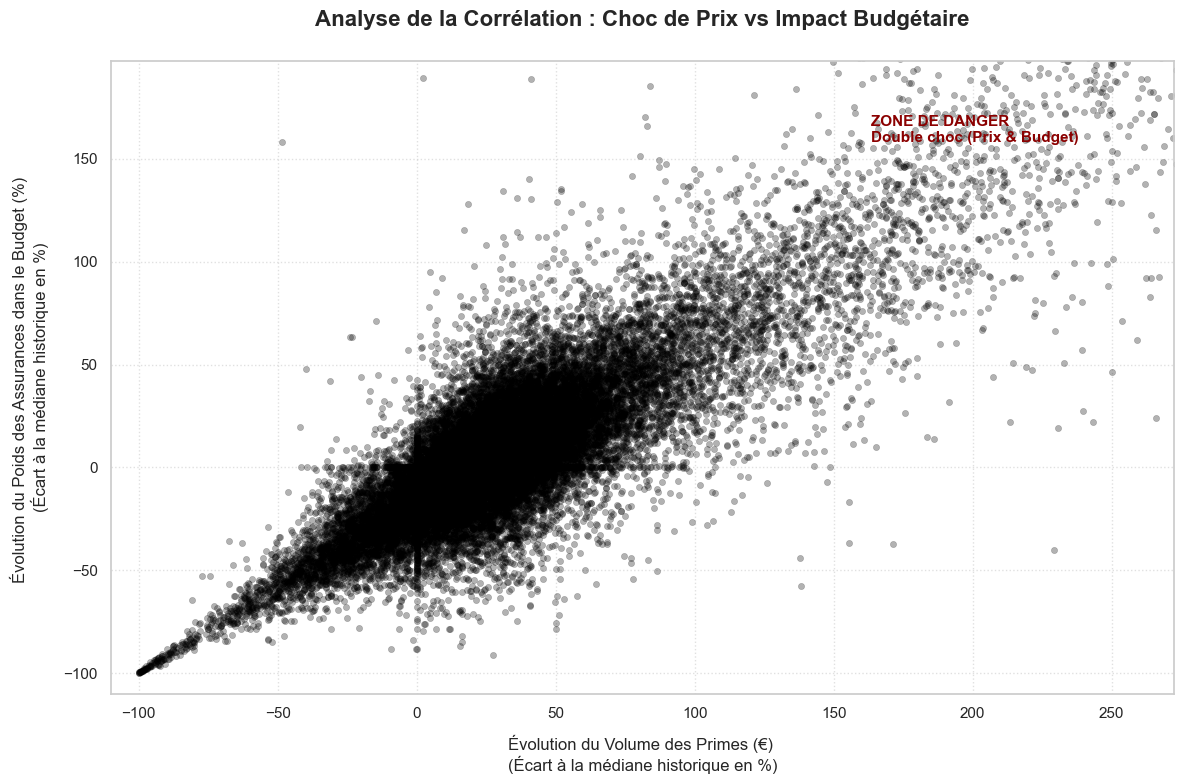

In [99]:
x_limit = comparison_combined["pct_change_vs_median_primes"].quantile(0.99)
y_limit = comparison_combined["pct_change_vs_median_primes_ratio"].quantile(0.99)

plt.figure(figsize=(12, 8))
g = sns.scatterplot(
    data=comparison_combined, 
    x="pct_change_vs_median_primes", 
    y="pct_change_vs_median_primes_ratio",
    alpha=0.3,          
    s=20,               
    color="black",
    edgecolor=None      
)

"""
sns.scatterplot(
    data=comparison_combined[(comparison_combined["pct_change_vs_median_vol"] == 0) | (comparison_combined["pct_change_vs_median_ratio"] == 0)], 
    x="pct_change_vs_median_vol", 
    y="pct_change_vs_median_ratio",
    alpha=0.3,          
    s=20,               
    color="red",
    edgecolor=None,
    ax=g
)
"""

g.set_xlim(-110, x_limit)
g.set_ylim(-110, y_limit)

plt.title("Analyse de la Corrélation : Choc de Prix vs Impact Budgétaire", fontsize=16, pad=25, fontweight='bold')
g.set_xlabel("Évolution du Volume des Primes (€) \n(Écart à la médiane historique en %)", fontsize=12, labelpad=10)
g.set_ylabel("Évolution du Poids des Assurances dans le Budget (%) \n(Écart à la médiane historique en %)", fontsize=12, labelpad=10)

plt.text(x_limit*0.6, y_limit*0.8, "ZONE DE DANGER\nDouble choc (Prix & Budget)", 
         color='darkred', fontsize=11, fontweight='bold')

#plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

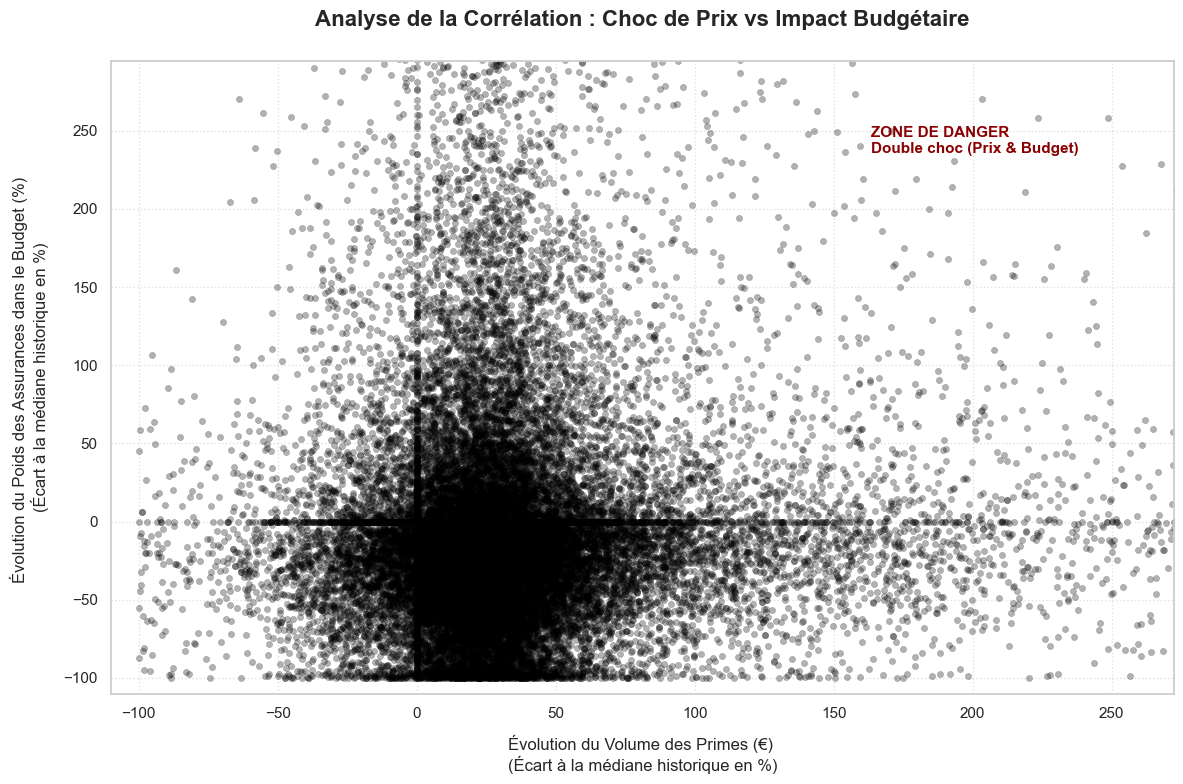

In [100]:
x_limit = comparison_combined["pct_change_vs_median_primes"].quantile(0.99)
y_limit = comparison_combined["pct_change_vs_median_dettes"].quantile(0.95)

plt.figure(figsize=(12, 8))
g = sns.scatterplot(
    data=comparison_combined, 
    x="pct_change_vs_median_primes", 
    y="pct_change_vs_median_dettes",
    alpha=0.3,          
    s=20,               
    color="black",
    edgecolor=None      
)

"""
sns.scatterplot(
    data=comparison_combined[(comparison_combined["pct_change_vs_median_vol"] == 0) | (comparison_combined["pct_change_vs_median_ratio"] == 0)], 
    x="pct_change_vs_median_vol", 
    y="pct_change_vs_median_ratio",
    alpha=0.3,          
    s=20,               
    color="red",
    edgecolor=None,
    ax=g
)
"""

g.set_xlim(-110, x_limit)
g.set_ylim(-110, y_limit)

plt.title("Analyse de la Corrélation : Choc de Prix vs Impact Budgétaire", fontsize=16, pad=25, fontweight='bold')
g.set_xlabel("Évolution du Volume des Primes (€) \n(Écart à la médiane historique en %)", fontsize=12, labelpad=10)
g.set_ylabel("Évolution du Poids des Assurances dans le Budget (%) \n(Écart à la médiane historique en %)", fontsize=12, labelpad=10)

plt.text(x_limit*0.6, y_limit*0.8, "ZONE DE DANGER\nDouble choc (Prix & Budget)", 
         color='darkred', fontsize=11, fontweight='bold')

#plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

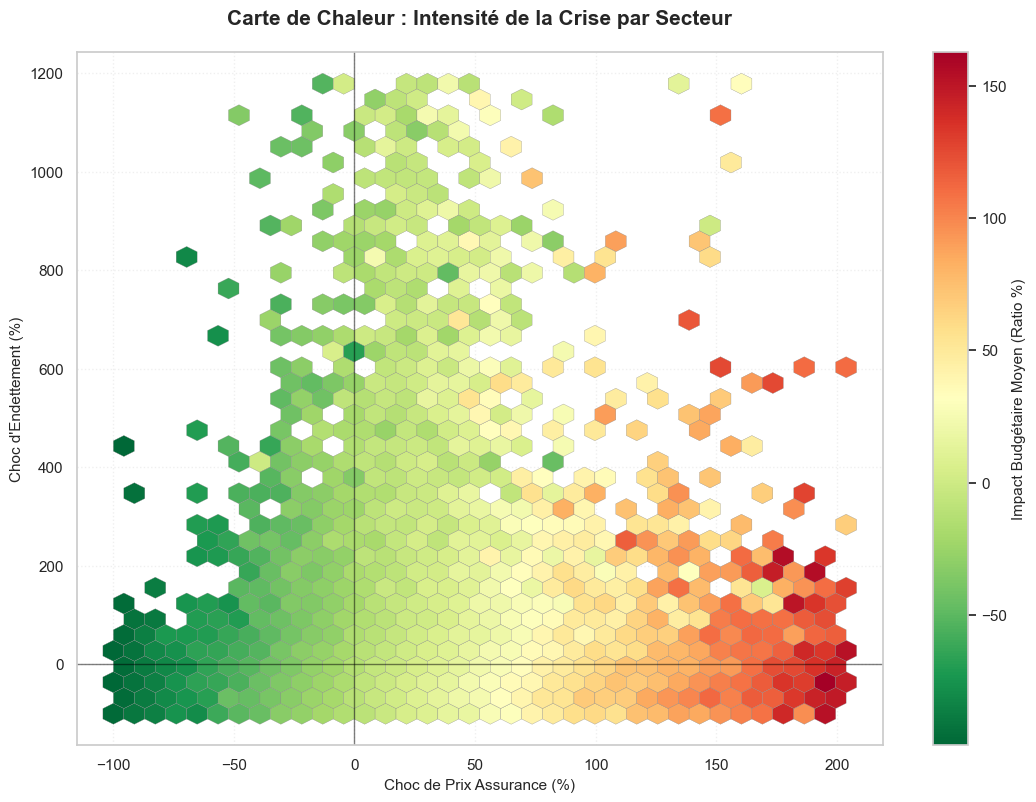

In [112]:
x_limit = comparison_combined["pct_change_vs_median_primes"].quantile(0.98)
y_limit = comparison_combined["pct_change_vs_median_dettes"].quantile(0.98)

# Filtrage pour le rendu
df_plot = comparison_combined[
    (comparison_combined["pct_change_vs_median_primes"].between(-100, x_limit)) &
    (comparison_combined["pct_change_vs_median_dettes"].between(-100, y_limit))
]

plt.figure(figsize=(13, 9))

hb = plt.hexbin(
    x=df_plot["pct_change_vs_median_primes"], 
    y=df_plot["pct_change_vs_median_dettes"],
    C=df_plot["pct_change_vs_median_primes_ratio"], 
    reduce_C_function=np.mean,
    gridsize=35, 
    cmap='RdYlGn_r', 
    mincnt=1,
    edgecolors='grey',
    linewidths=0.2
)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)

cb = plt.colorbar(hb)
cb.set_label("Impact Budgétaire Moyen (Ratio %)", fontsize=11)

plt.title("Carte de Chaleur : Intensité de la Crise par Secteur", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Choc de Prix Assurance (%)", fontsize=11)
plt.ylabel("Choc d'Endettement (%)", fontsize=11)

plt.grid(True, linestyle=':', alpha=0.3)
plt.show()

In [129]:
# https://mpltern.readthedocs.io/en/latest/

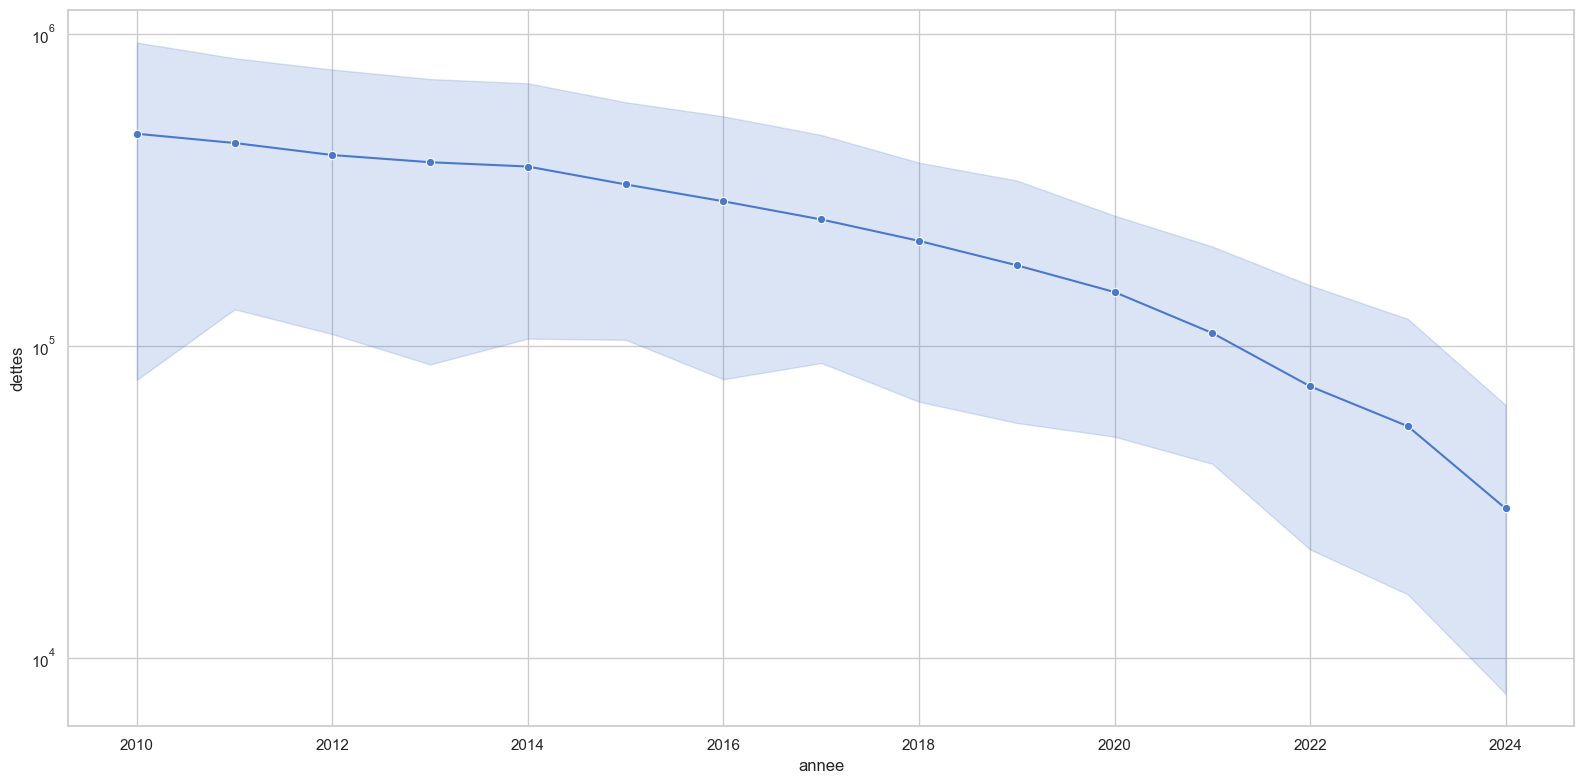

In [104]:
sample = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] < -80) & (comparison_combined["pct_change_vs_median_dettes"] < -80)]#.head(20)

plt.figure(figsize=(16, 8))

ax = sns.lineplot(
    data=comptes_final[comptes_final["code_geo_from_siren"].isin(sample["code_geo_from_siren"])],
    x="annee",
    y="dettes",
    #hue="nom_com",
    marker='o',
)

plt.yscale('log')

plt.tight_layout()
plt.show()

In [103]:
sample

,code_geo_from_siren,nom_com,region_name,yoy_growth_primes,pct_change_vs_median_primes,rank_delta_primes,cagr_3y_primes,yoy_growth_primes_ratio,pct_change_vs_median_primes_ratio,rank_delta_primes_ratio,cagr_3y_primes_ratio,yoy_growth_dettes,pct_change_vs_median_dettes,rank_delta_dettes,cagr_3y_dettes
34540,54501,Seranville,Grand Est,-83.849496,-81.768562,-3031.0,-41.796073,-81.832655,-81.109310,-20135.0,-41.109438,5.500000e+10,-97.281998,-2137.0,0.613512
34554,55327,Mauvages,Grand Est,-86.054447,-87.490952,-12080.0,-54.569157,-87.924963,-86.948616,-20077.0,-53.523180,0.000000e+00,-93.846468,-2436.0,-38.988771
34567,17120,Corme-Royal,Nouvelle-Aquitaine,-87.658530,-83.357328,-23635.0,-57.885083,-87.591556,-85.855991,-11905.0,-58.519225,-4.220616e+01,-82.510090,-11254.0,-31.748838
34578,23213,Saint-Marien,Nouvelle-Aquitaine,-88.735231,-88.187214,-8931.0,-55.730420,-92.875843,-92.186288,-9459.0,-57.248390,-7.694339e+01,-97.234949,-4509.0,-57.651344
34595,82133,Mouillac,Occitanie,-91.874517,-82.854266,-999.0,-58.063003,-92.681353,-88.156186,-23792.0,-60.498866,0.000000e+00,-96.459522,-1579.5,0.000000
34602,59111,Broxeele,Hauts-de-France,-92.713189,-89.096867,-10329.0,-57.795138,-91.379845,-93.350332,-18520.0,-57.559352,0.000000e+00,-97.999036,-2930.0,-85.224367
34621,10014,Assencières,Grand Est,-95.445803,-88.377654,-3565.0,-52.076379,-95.136691,-89.629971,-29116.0,-54.169249,-1.000000e+02,-100.000000,-8692.5,-99.970146
34627,62455,Hocquinghen,Hauts-de-France,-95.921550,-95.154780,-4612.0,-64.541632,-95.256906,-95.337304,-31063.0,-65.207767,-4.224387e+01,-85.153502,-742.0,-31.427293
34647,64001,Aast,Nouvelle-Aquitaine,-98.298956,-95.731927,-4657.5,-65.603680,-97.308505,-94.829885,-22663.0,-61.549955,-9.871155e+01,-95.799630,-2222.5,-76.556523
34652,22145,Mégrit,Bretagne,-98.530007,-98.236882,-17391.0,-74.262343,-98.635055,-98.390012,-6401.0,-75.363582,-9.989354e+00,-80.877818,-10631.0,-8.784162


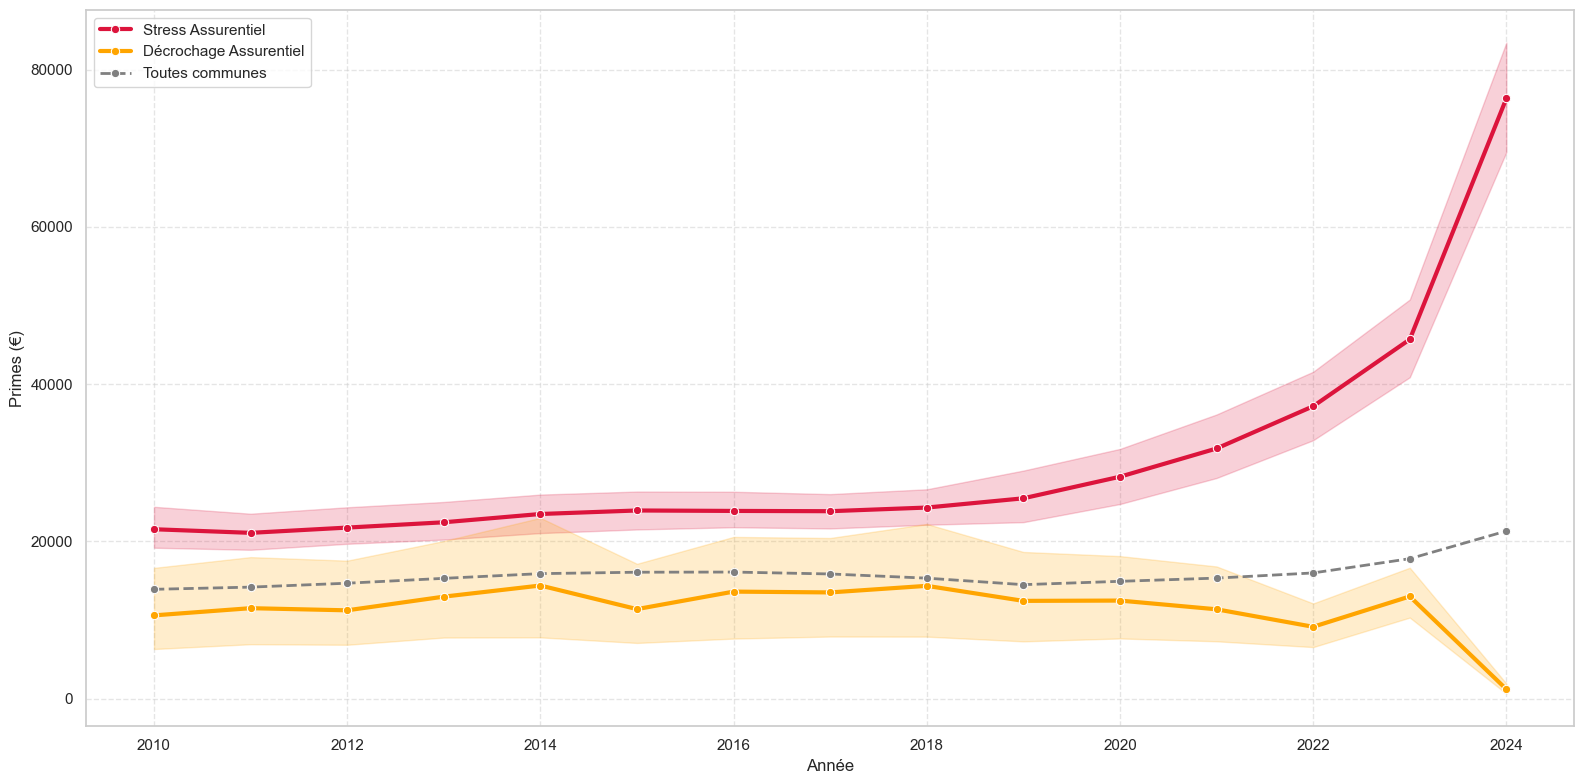

In [177]:
above = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] > 100) & (comparison_combined["pct_change_vs_median_primes_ratio"] > 100)] 
below = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] < -80) & (comparison_combined["pct_change_vs_median_primes_ratio"] < -80)] 

plt.figure(figsize=(16, 8))

sns.lineplot(
    data=comptes_final[comptes_final["code_geo_from_siren"].isin(above["code_geo_from_siren"])],
    x="annee",
    y="primes",
    marker='o',
    color='crimson',
    linewidth=3,
    label="Stress Assurentiel",
    errorbar=('ci', 95)
)

sns.lineplot(
    data=comptes_final[comptes_final["code_geo_from_siren"].isin(below["code_geo_from_siren"])],
    x="annee",
    y="primes",
    marker='o',
    color='orange',
    linewidth=3,
    label="Décrochage Assurentiel",
    errorbar=('ci', 95)
)


sns.lineplot(
    data=comptes_final,
    x="annee",
    y="primes",
    marker='o',
    color='gray',
    linewidth=2,
    linestyle='--',
    label="Toutes communes",
    errorbar=None
)

plt.title("", fontsize=16, pad=20)
plt.xlabel("Année", fontsize=12)
#plt.ylabel("Ratio Primes / Dépenses (%)", fontsize=12)
plt.ylabel("Primes (€)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

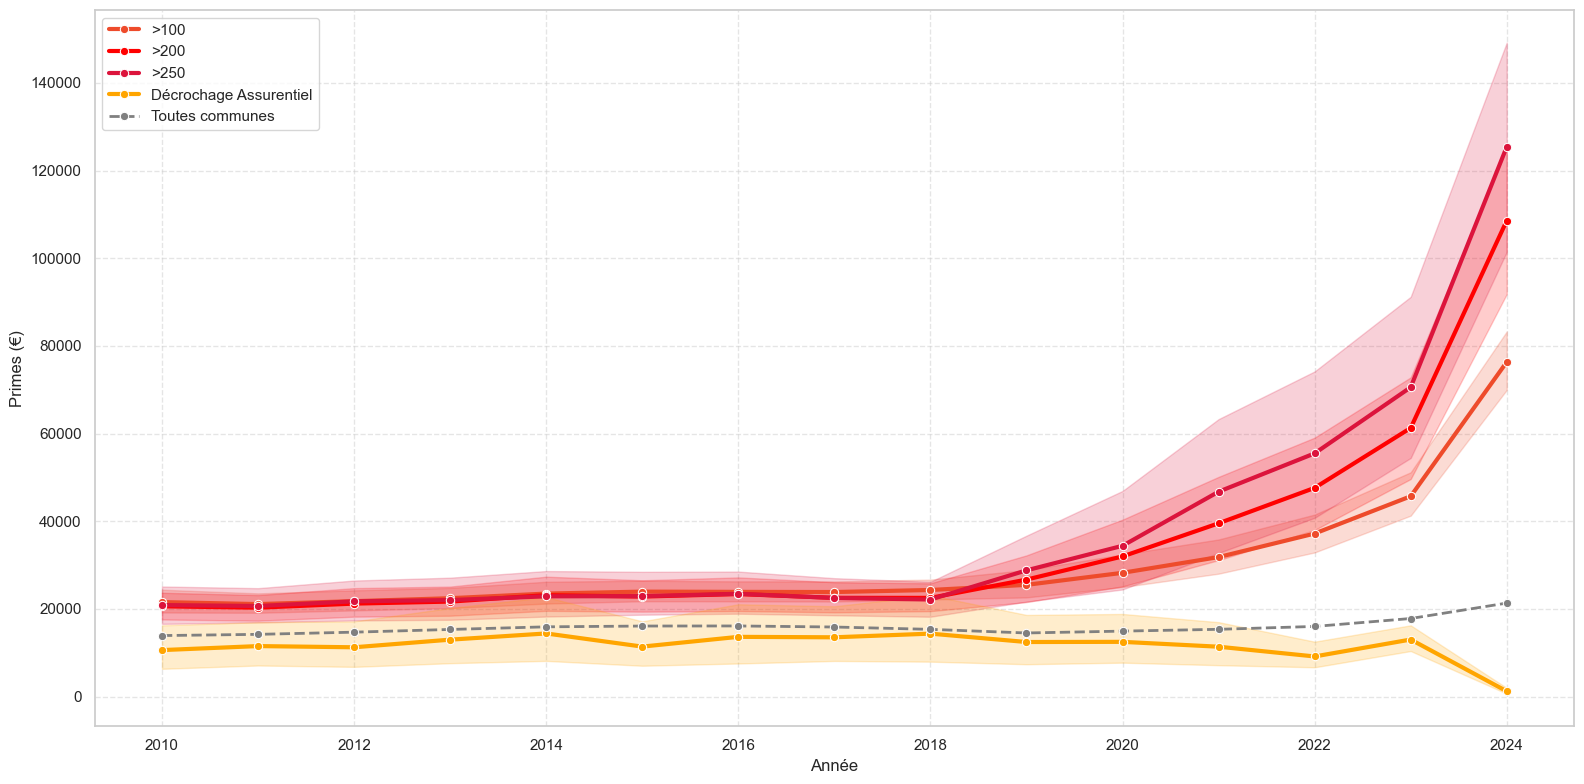

In [175]:
above_100 = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] > 100) & (comparison_combined["pct_change_vs_median_primes_ratio"] > 100)] 
above_200 = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] > 200) & (comparison_combined["pct_change_vs_median_primes_ratio"] > 200)] 
above_250 = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] > 250) & (comparison_combined["pct_change_vs_median_primes_ratio"] > 250)] 
below = comparison_combined[(comparison_combined["pct_change_vs_median_primes"] < -80) & (comparison_combined["pct_change_vs_median_primes_ratio"] < -80)] 

plt.figure(figsize=(16, 8))

for above, color, label in zip([above_100, above_200, above_250], 
                               ["#EE4B2B", "red", "crimson"], 
                               [">100", ">200", ">250"]):
    sns.lineplot(
        data=comptes_final[comptes_final["code_geo_from_siren"].isin(above["code_geo_from_siren"])],
        x="annee",
        y="primes",
        marker='o',
        color=color,
        linewidth=3,
        label=label,
        errorbar=('ci', 95)
    )

sns.lineplot(
    data=comptes_final[comptes_final["code_geo_from_siren"].isin(below["code_geo_from_siren"])],
    x="annee",
    y="primes",
    marker='o',
    color='orange',
    linewidth=3,
    label="Décrochage Assurentiel",
    errorbar=('ci', 95)
)


sns.lineplot(
    data=comptes_final,
    x="annee",
    y="primes",
    marker='o',
    color='gray',
    linewidth=2,
    linestyle='--',
    label="Toutes communes",
    errorbar=None
)

plt.title("", fontsize=16, pad=20)
plt.xlabel("Année", fontsize=12)
#plt.ylabel("Ratio Primes / Dépenses (%)", fontsize=12)
plt.ylabel("Primes (€)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

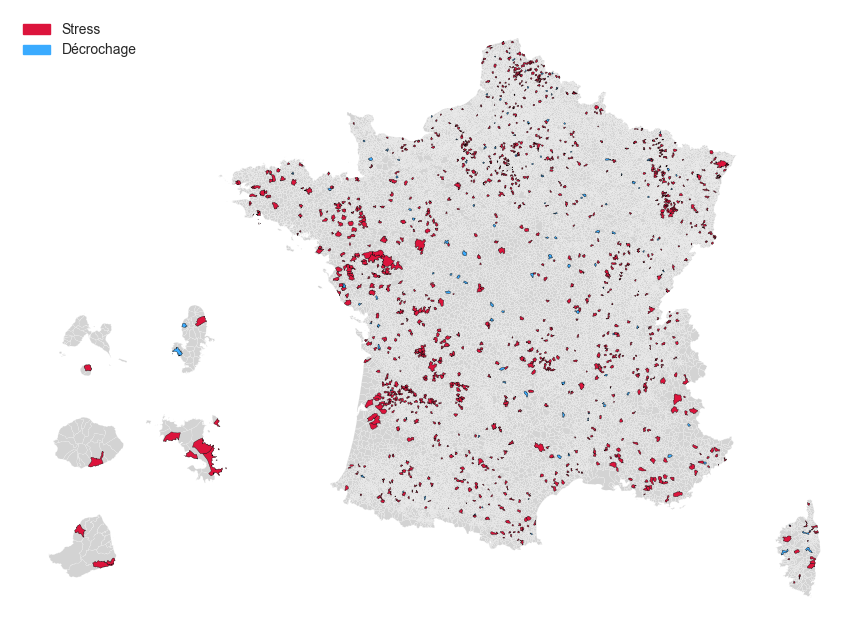

In [178]:
communes_geo_prep, drom_configs = prepare_france_geometry(communes_geo)
communes_above_geo = communes_geo_prep.merge(above, left_on="code", right_on="code_geo_from_siren")
communes_below_geo = communes_geo_prep.merge(below, left_on="code", right_on="code_geo_from_siren")

fig, ax = plt.subplots(figsize=(16, 8))

communes_geo_prep.plot(color="lightgrey", edgecolor="white", linewidth=0.1, ax=ax)
communes_above_geo.plot(color="crimson", edgecolor="black", linewidth=0.25, ax=ax)
communes_below_geo.plot(color="#3aabff", edgecolor="black", linewidth=0.25, ax=ax)

red_patch = mpatches.Patch(color='crimson', label='Stress')
orange_patch = mpatches.Patch(color='#3aabff', label='Décrochage')

ax.legend(handles=[red_patch, orange_patch], 
          loc='upper left', 
          frameon=False, 
          fontsize=10, 
          title="")

# Esthétique
ax.grid(False)
ax.set_title("", fontsize=15, pad=20)
plt.axis('off')

plt.show()

In [1006]:
Q1 = comparison_df['yoy_growth'].quantile(0.25)
Q3 = comparison_df['yoy_growth'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
"""
years = sorted(dettes_reunion['annee'].unique())
pal = sns.color_palette(palette='coolwarm', n_colors=len(years))

g = sns.FacetGrid(dettes_reunion, row='annee', hue='annee', aspect=15, height=0.75, palette=pal)

g.map(sns.kdeplot, 'solde',
      bw_adjust=1, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

g.map(sns.kdeplot, 'solde', 
      bw_adjust=1, clip_on=False, 
      color="w", lw=2)

g.map(plt.axhline, y=0,
      lw=2, clip_on=False)

min_x = dettes_reunion['solde'].min()
for i, ax in enumerate(g.axes.flat):
    ax.grid(False)
    ax.text(-min_x/5, 0.5e-8, str(years[i]), # Use years[i] instead of i+1
            fontweight='bold', fontsize=12,
            color=ax.lines[-1].get_color(),
            ha='left')

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

g.fig.subplots_adjust(hspace=-0.3)

g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True)

plt.xlabel('Solde de la dette (€)', fontweight='bold', fontsize=15)
g.fig.suptitle('Évolution de la distribution de la dette : La Réunion',
               ha='center', fontsize=20, fontweight='bold')

plt.show()
"""

"""
dettes_dept = dettes[dettes["code_departement"] == "92"].groupby(['code_geo','annee'])["solde"].sum().reset_index()

min_solde = dettes_dept['solde'].min()
max_solde = dettes_dept['solde'].max()

dettes_dept = dettes_dept.sort_values("annee")

fig = px.choropleth_mapbox(
    dettes_dept,
    geojson="https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson",
    locations="code_geo",      
    featureidkey="properties.code", 
    color="solde",            
    animation_frame="annee",    
    hover_name="code_geo",
    
    range_color=[min_solde, max_solde], 
    
    mapbox_style="carto-darkmatter",
    color_continuous_scale="Viridis",
    center={"lat": 46.2276, "lon": 2.2137}, 
    zoom=4.5,
    opacity=0.7,
    labels={'solde': 'Dette (Solde) (€)'}
)

fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0}, 
    title="Debt Evolution by Department (Standardized Scale)",
    coloraxis_colorbar=dict(title="Solde (€)")
)

#fig.show()
fig.write_html("dettes_ts_map.html")
"""